In [3]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

## Data Aquisation


In [4]:
print("Loading data...")
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_test_images = X_test

Loading data...
11490434/11490434 [==============================] - 2s 0us/step


## Preprocessing & Normalization

In [5]:
X_train = X_train.reshape(-1, 784) / 255.0
X_test = X_test.reshape(-1, 784) / 255.0

## Lable Encoding

In [6]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

## Model Architecture and training

In [7]:
with tf.device('/GPU:0'):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(784,)),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

## Training

In [8]:
print("\nStarting training...")
history = model.fit(
    X_train, y_train_cat,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Starting training...
Epoch 1/50
1688/1688 [==============================] - 4s 2ms/step - loss: 0.2514 - accuracy: 0.9253 - val_loss: 0.1122 - val_accuracy: 0.9670
Epoch 2/50
1688/1688 [==============================] - 4s 2ms/step - loss: 0.1055 - accuracy: 0.9682 - val_loss: 0.1055 - val_accuracy: 0.9685
Epoch 3/50
1688/1688 [==============================] - 4s 3ms/step - loss: 0.0731 - accuracy: 0.9771 - val_loss: 0.0862 - val_accuracy: 0.9765
Epoch 4/50
1688/1688 [==============================] - 4s 3ms/step - loss: 0.0561 - accuracy: 0.9815 - val_loss: 0.0867 - val_accuracy: 0.9745
Epoch 5/50
1688/1688 [==============================] - 5s 3ms/step - loss: 0.0417 - accuracy: 0.9867 - val_loss: 0.0693 - val_accuracy: 0.9787
Epoch 6/50
1688/1688 [==============================] - 5s 3ms/step - loss: 0.0339 - accuracy: 0.9892 - val_loss: 0.0850 - val_accuracy: 0.9775
Epoch 7/50
1688/1688 [==============================] - 4s 3ms/step - loss: 0.0289 - accuracy: 0.9906 - val_loss: 

## Plotting Training History

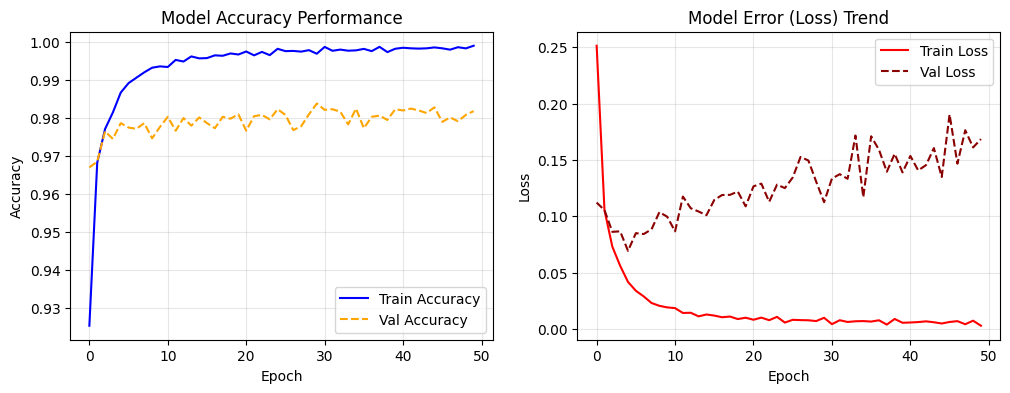

In [9]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange', linestyle='--')
plt.title('Model Accuracy Performance')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='red')
plt.plot(history.history['val_loss'], label='Val Loss', color='darkred', linestyle='--')
plt.title('Model Error (Loss) Trend')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Generating predictions on unseen test data...
313/313 [==============================] - 0s 1ms/step


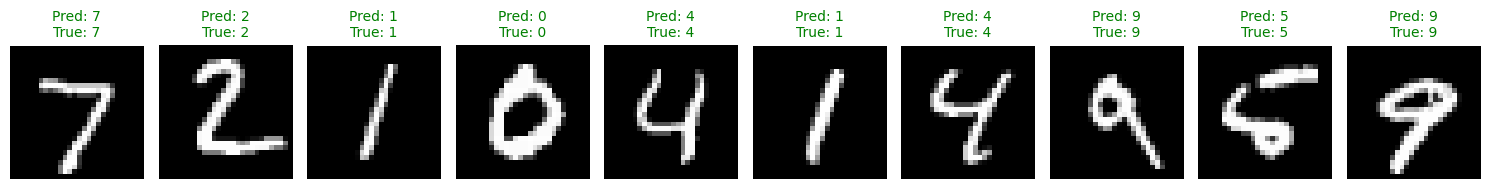

In [10]:
print("\nGenerating predictions on unseen test data...")
predictions = model.predict(X_test)

plt.figure(figsize=(15, 3))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(X_test_images[i], cmap='gray')
    
    pred_label = np.argmax(predictions[i])
    true_label = y_test[i]
    
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [11]:
loss, accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\n[FINAL REPORT] Test Loss: {loss:.4f}")
print(f"[FINAL REPORT] Test Accuracy: {accuracy*100:.2f}%")


[FINAL REPORT] Test Loss: 0.1752
[FINAL REPORT] Test Accuracy: 98.04%
